# Chapter 11 — Classification

This notebook accompanies **Chapter 11** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

Classification tasks predict a **categorical** outcome variable.  This chapter develops two probabilistic approaches:

* **Binary logistic regression** — models the log odds of the positive class as a linear function of predictors; fitted by minimising (regularised) cross-entropy loss.
* **Multinomial (softmax) logistic regression** — generalises to $K > 2$ classes using the softmax function.
* **$k$-nearest neighbours (k-NN)** — a non-parametric method that estimates class probabilities from the $k$ closest training points.

Throughout we use two datasets:

* **Diabetes dataset** (§11.1–11.3): 1 879 patients, 5 core predictors, binary outcome.
* **Human speech sounds** (§11.5–11.7): 2 371 vowel utterances, 10 syllable classes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

rng = np.random.default_rng(42)

In [ ]:
try:
    import google.colab
    DATA_PATH = "https://inferencebook.github.io/data/"
except ImportError:
    DATA_PATH = "../data/"


---
## §11.1 The diabetes dataset

> **Book link — §11.1.**  Table 11.1 lists five predictors tracked for each of the 1 879 patients; Table 11.2 shows the first few rows.

The response variable `Diagnosis` is 1 if the patient has diabetes, 0 otherwise.

In [2]:
df = pd.read_csv(DATA_PATH + 'diabetes_data.csv')

FEATURE_COLS = ['FastingBloodSugar', 'HbA1c', 'CholesterolTriglycerides',
                'Hypertension', 'SocioeconomicStatus']
FEATURE_NAMES = ['Fasting blood sugar', 'Hemoglobin A1C',
                 'Cholesterol triglycerides', 'Hypertension', 'Socioeconomic status']
TARGET_COL = 'Diagnosis'

# 5-feature matrix and response
X5_raw = df[FEATURE_COLS].values.astype(float)
y      = df[TARGET_COL].values.astype(float)

n, p = X5_raw.shape
pi_hat = y.mean()   # base rate of diabetes

print(f"n = {n} patients,  {p} features")
print(f"Diabetes (y=1): {int(y.sum())}  ({100*pi_hat:.1f}%)")
print(f"Base-rate cross-entropy loss: {-(pi_hat*np.log(pi_hat)+(1-pi_hat)*np.log(1-pi_hat)):.4f}")
df[FEATURE_COLS + [TARGET_COL]].head()

n = 1879 patients,  5 features
Diabetes (y=1): 752  (40.0%)
Base-rate cross-entropy loss: 0.6731


,FastingBloodSugar,HbA1c,CholesterolTriglycerides,Hypertension,SocioeconomicStatus,Diagnosis
0,163.687162,9.283631,190.335834,0,2,1
1,188.347070,7.326870,81.172469,0,1,1
2,127.703653,4.083426,279.809069,0,1,0
3,82.688415,6.516645,112.751396,0,1,0
4,90.743395,5.607222,381.528785,0,1,0


---
## §11.2 Cross-entropy loss

> **Book link — §11.2 (eq. 11.3).**  For a probabilistic binary classifier $g$ and dataset $D$,  the cross-entropy loss is
> $$l(g; D) = -\frac{1}{n}\sum_{(x,y)\in D}\bigl(y\log g(x) + (1-y)\log(1-g(x))\bigr).$$
> A classifier that always predicts the base rate $\hat{\pi}$ achieves loss $-(\hat{\pi}\log\hat{\pi} + (1-\hat{\pi})\log(1-\hat{\pi}))$.  With $\hat{\pi}=0.4$ this equals **0.673** — the baseline to beat.

---
## §11.3.1 Binary logistic regression — the logit link

> **Book link — §11.3.1, Figure 11.1.**  The *logit* function transforms a probability $p\in(0,1)$ to the real line;
> its inverse — the *standard sigmoid* $\sigma(z)=(1+e^{-z})^{-1}$ — maps any real number back to $(0,1)$.
> $$\operatorname{logit}(p) = \log\frac{p}{1-p}, \qquad \sigma(z) = \frac{1}{1+e^{-z}}.$$

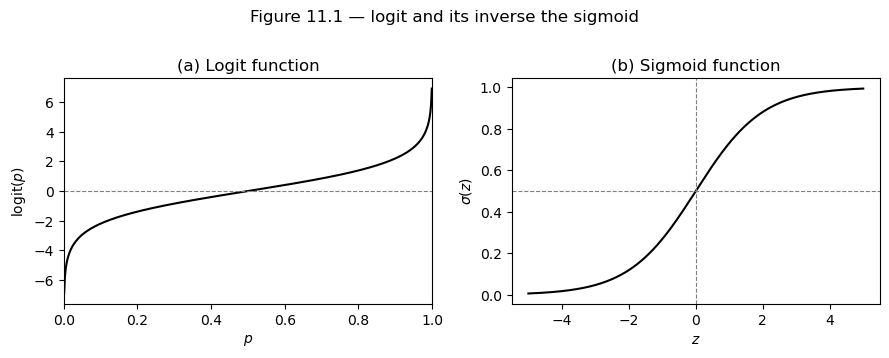

In [3]:
# Figure 11.1 — logit and sigmoid
p_grid = np.linspace(0.001, 0.999, 500)
z_grid = np.linspace(-5, 5, 500)

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(9, 3.5))

ax_a.plot(p_grid, np.log(p_grid / (1 - p_grid)), 'k', lw=1.5)
ax_a.axhline(0, color='grey', lw=0.8, ls='--')
ax_a.set_xlabel('$p$'); ax_a.set_ylabel('logit$(p)$')
ax_a.set_title('(a) Logit function'); ax_a.set_xlim(0, 1)

ax_b.plot(z_grid, 1 / (1 + np.exp(-z_grid)), 'k', lw=1.5)
ax_b.axhline(0.5, color='grey', lw=0.8, ls='--')
ax_b.axvline(0,   color='grey', lw=0.8, ls='--')
ax_b.set_xlabel('$z$'); ax_b.set_ylabel(r'$\sigma(z)$')
ax_b.set_title('(b) Sigmoid function')

plt.suptitle('Figure 11.1 — logit and its inverse the sigmoid', y=1.01)
plt.tight_layout(); plt.show()

---
## §11.3.2 Simple logistic regression on each predictor

> **Book link — §11.3.2, Figure 11.2.**  We fit five separate single-predictor models by
> maximising the unregularised likelihood.  Each panel shows the fitted sigmoid
> together with jittered training data coloured by diagnosis (blue = diabetic, orange = healthy).

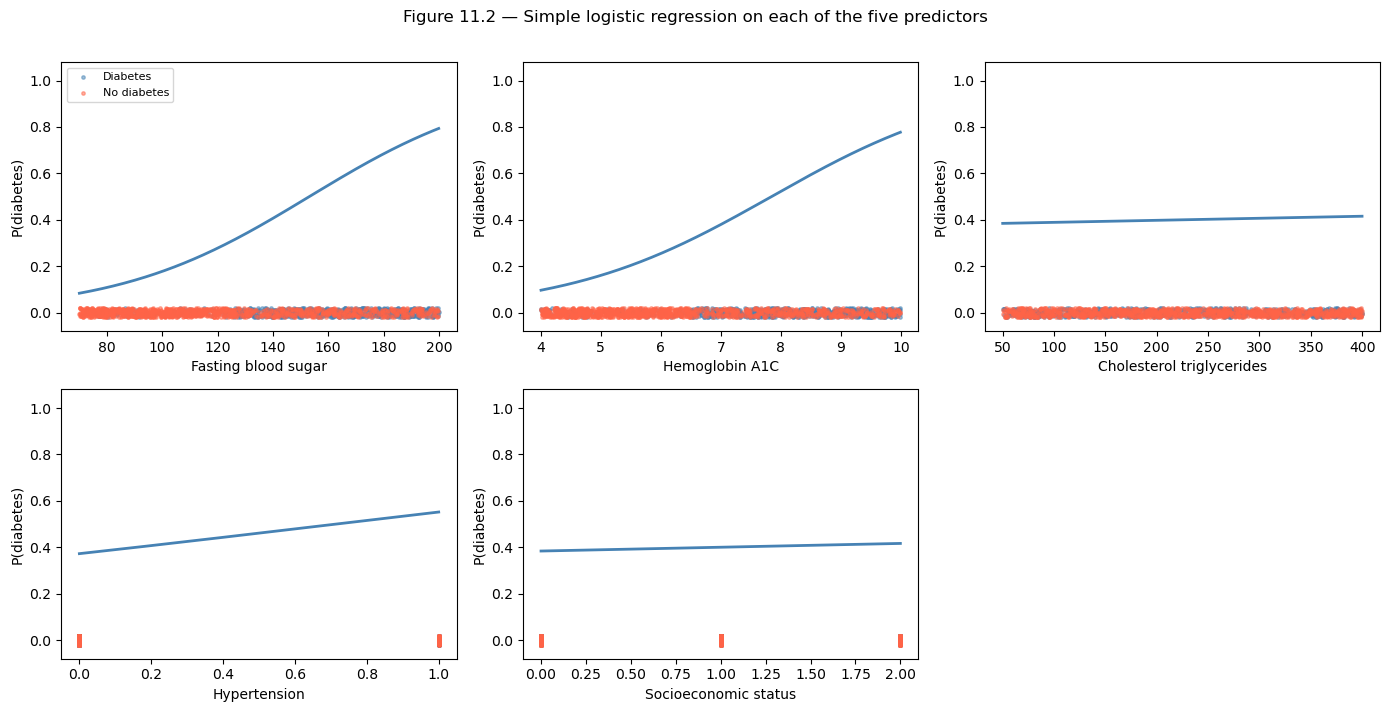

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for j, (col, name) in enumerate(zip(FEATURE_COLS, FEATURE_NAMES)):
    ax = axes[j]
    xj = X5_raw[:, j:j+1]

    pipe_j = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000))
    ])
    pipe_j.fit(xj, y)

    x_grid  = np.linspace(xj.min(), xj.max(), 300).reshape(-1, 1)
    p_curve = pipe_j.predict_proba(x_grid)[:, 1]

    ax.plot(x_grid[:, 0], p_curve, 'steelblue', lw=2)
    jitter = rng.uniform(-0.02, 0.02, size=n)
    for cls, clr, lbl in [(1, 'steelblue', 'Diabetes'), (0, 'tomato', 'No diabetes')]:
        mask = (y == cls)
        ax.scatter(xj[mask, 0], jitter[mask], c=clr, s=6, alpha=0.5, label=lbl)

    ax.set_xlabel(name); ax.set_ylabel('P(diabetes)')
    ax.set_ylim(-0.08, 1.08)

axes[-1].axis('off')
axes[0].legend(fontsize=8, loc='upper left')
plt.suptitle('Figure 11.2 — Simple logistic regression on each of the five predictors', y=1.01)
plt.tight_layout(); plt.show()

### Table 11.3 — Coefficients, bootstrap SEs, and CV performance

> **Book link — §11.3.2, Table 11.3.**  Standard errors use 1 000 non-parametric bootstrap
> resamples.  Starred coefficients ($\hat\beta_1^*$) are on standardised predictors.
> CV scores use stratified 5-fold cross-validation without regularisation.

In [5]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

# Bootstrap SEs — refit each single-predictor model on each resample
N_BOOT = 1000
boot_betas = np.zeros((N_BOOT, len(FEATURE_COLS)))

for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    for j in range(len(FEATURE_COLS)):
        xj_b = X5_raw[idx, j:j+1]
        pipe_b = Pipeline([
            ('scaler', StandardScaler()),
            ('clf',    LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000))
        ])
        pipe_b.fit(xj_b, y[idx])
        boot_betas[b, j] = pipe_b.named_steps['clf'].coef_[0, 0]

se_boot = boot_betas.std(axis=0)

print(f"{'Predictor':<30} {'β̂*':>8} {'ŝe(β̂*)':>10} {'CV CE':>8} {'CV acc':>8}")
print("-" * 70)
for j, name in enumerate(FEATURE_NAMES):
    xj = X5_raw[:, j:j+1]
    pipe_j = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000))
    ])
    pipe_j.fit(xj, y)
    beta_star = pipe_j.named_steps['clf'].coef_[0, 0]

    res = cross_validate(pipe_j, xj, y, cv=cv5,
                         scoring=['neg_log_loss', 'accuracy'])
    cv_ce  = -res['test_neg_log_loss'].mean()
    cv_acc =  res['test_accuracy'].mean()
    print(f"{name:<30} {beta_star:>8.4f} {se_boot[j]:>10.4f} {cv_ce:>8.3f} {cv_acc:>8.3f}")

print()
print("(Table 11.3 targets: FBS β*≈1.080 se≈0.059  CV acc≈0.680)")
print("                     HbA1c β*≈1.012 se≈0.057  CV acc≈0.668")

Predictor                           β̂*    ŝe(β̂*)    CV CE   CV acc
----------------------------------------------------------------------
Fasting blood sugar              1.0804     0.0607    0.564    0.680
Hemoglobin A1C                   1.0118     0.0563    0.575    0.666
Cholesterol triglycerides        0.0371     0.0482    0.674    0.600
Hypertension                     0.2628     0.0477    0.665    0.616
Socioeconomic status             0.0522     0.0471    0.673    0.600

(Table 11.3 targets: FBS β*≈1.080 se≈0.059  CV acc≈0.680)
                     HbA1c β*≈1.012 se≈0.057  CV acc≈0.668


---
## §11.3.3 Why regularisation is needed — linear separability

> **Book link — §11.3.3, Figure 11.3.**  As the two classes become more distinct, the
> unregularised MLE sigmoid becomes sharper.  When classes are *linearly separable* (panel d)
> there is no MLE: the loss keeps falling as $|\beta_1| \to \infty$.

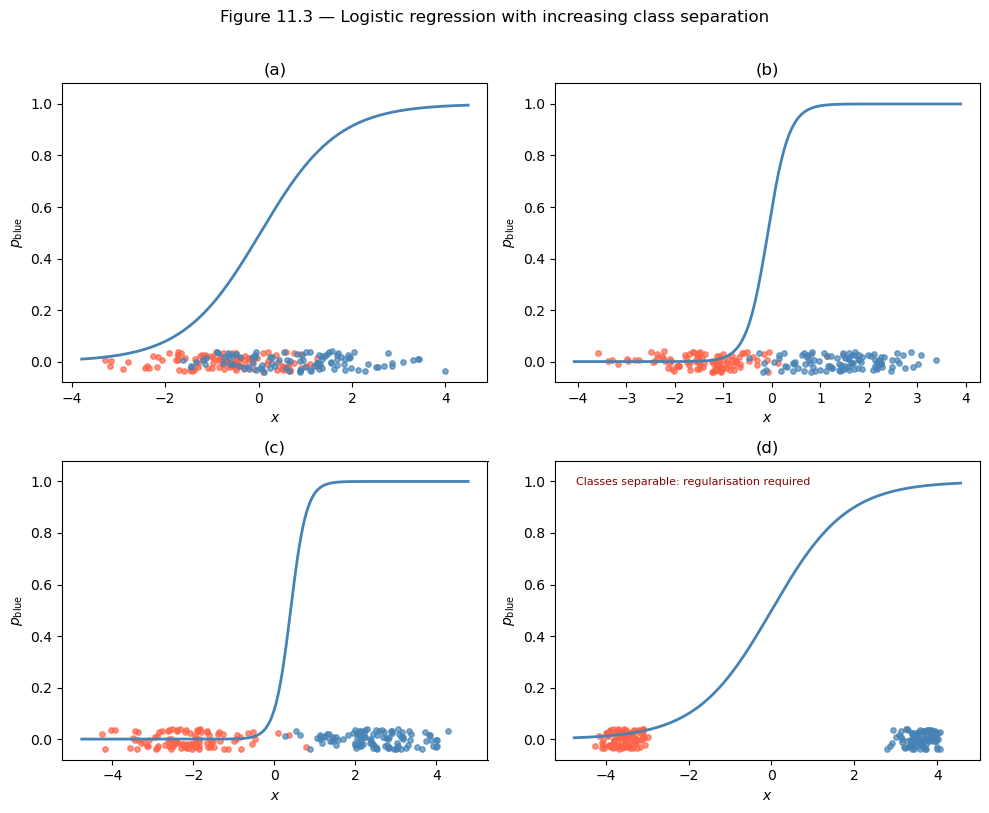

In [6]:
# Simulate four datasets with increasing class separation
datasets = [
    (rng.normal(-0.8, 1.2, 100), rng.normal(0.8, 1.2, 100)),   # (a) overlapping
    (rng.normal(-1.5, 0.9, 100), rng.normal(1.5, 0.9, 100)),   # (b) more distinct
    (rng.normal(-2.2, 0.9, 100), rng.normal(2.2, 0.9, 100)),   # (c) quite distinct
    (rng.normal(-3.5, 0.3, 100), rng.normal(3.5, 0.3, 100)),   # (d) linearly separable
]
# For (a)–(c) use a very large C (≈ no regularisation).
# For the separable case (d) we must regularise: λ=0.5 → C=1.0.
Cs = [1e6, 1e6, 1e6, 1.0]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (neg_x, pos_x), C_d, title in zip(axes, datasets, Cs, ['(a)', '(b)', '(c)', '(d)']):
    X_d = np.concatenate([neg_x, pos_x]).reshape(-1, 1)
    y_d = np.array([0]*100 + [1]*100, dtype=float)

    pipe_d = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=C_d, solver='lbfgs', max_iter=2000))
    ])
    pipe_d.fit(X_d, y_d)

    x_grid  = np.linspace(X_d.min() - 0.5, X_d.max() + 0.5, 400).reshape(-1, 1)
    p_curve = pipe_d.predict_proba(x_grid)[:, 1]

    jitter_y = rng.uniform(-0.04, 0.04, size=200)
    ax.plot(x_grid[:, 0], p_curve, 'steelblue', lw=2)
    ax.scatter(neg_x, jitter_y[:100], c='tomato',    s=15, alpha=0.7)
    ax.scatter(pos_x, jitter_y[100:], c='steelblue', s=15, alpha=0.7)
    ax.set_title(title); ax.set_xlabel('$x$'); ax.set_ylabel(r'$p_{\rm blue}$')
    ax.set_ylim(-0.08, 1.08)
    if title == '(d)':
        ax.text(0.05, 0.92, 'Classes separable: regularisation required',
                transform=ax.transAxes, fontsize=8, color='darkred')

plt.suptitle('Figure 11.3 — Logistic regression with increasing class separation', y=1.01)
plt.tight_layout(); plt.show()

---
## §11.3.4 Regularisation strength: translating between λ and sklearn's C

> **Book link — §11.3.4.**  The regularised objective the text minimises is
> $$\frac{1}{n}\sum_{i=1}^n \text{CE}(\boldsymbol{\beta};\,x_i,y_i) \;+\; \frac{\lambda}{n}\|\boldsymbol{\beta}\|^2.$$
> sklearn's `LogisticRegression` instead minimises
> $$\frac{1}{2}\|\boldsymbol{\beta}\|^2 + C\sum_{i=1}^n \text{CE}(\boldsymbol{\beta};\,x_i,y_i).$$
> Setting the gradient to zero in each case and equating gives the exact correspondence
> $$\boxed{C \;=\; \frac{1}{2\lambda}}, \qquad \lambda \;=\; \frac{1}{2C}.$$
> The sample size $n$ cancels — the relationship holds for any dataset size.
>
> **Note the direction**: larger $\lambda$ means more regularisation; sklearn's C is the reciprocal, so a **smaller C** means more regularisation.  sklearn's default is `C=1.0`, which corresponds to $\lambda = 0.5$.

In [7]:
print(f"{'λ (textbook)':>14} {'C = 1/(2λ) (sklearn)':>22}")
print("-" * 38)
for lam in [0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    marker = '  ← sklearn default (C=1)' if lam == 0.5 else ''
    print(f"{lam:>14.2f} {1/(2*lam):>22.4f}{marker}")

  λ (textbook)   C = 1/(2λ) (sklearn)
--------------------------------------
          0.05                10.0000
          0.10                 5.0000
          0.50                 1.0000  ← sklearn default (C=1)
          1.00                 0.5000
          2.00                 0.2500
          5.00                 0.1000
         10.00                 0.0500


---
## §11.3.5 Multiple logistic regression on the diabetes dataset

> **Book link — §11.3.5, Box 11.1, Figure 11.4.**  All five predictors are scaled jointly
> inside a pipeline.  We scan over λ (equivalently C = 1/(2λ)) using stratified 5-fold CV,
> then zoom in on the optimal region.

In [8]:
# Coarse scan: λ ∈ [0.1, 2000]
lams_coarse   = np.logspace(-1, 3.3, 60)
ce_cv_coarse  = np.zeros(len(lams_coarse))
acc_cv_coarse = np.zeros(len(lams_coarse))

for i, lam in enumerate(lams_coarse):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1/(2*lam), solver='lbfgs', max_iter=1000))
    ])
    res = cross_validate(pipe, X5_raw, y, cv=cv5,
                         scoring=['neg_log_loss', 'accuracy'])
    ce_cv_coarse[i]  = -res['test_neg_log_loss'].mean()
    acc_cv_coarse[i] =  res['test_accuracy'].mean()

# Fine scan: λ ∈ [0.01, 4]
lams_fine   = np.linspace(0.01, 4, 80)
ce_cv_fine  = np.zeros(len(lams_fine))
acc_cv_fine = np.zeros(len(lams_fine))

for i, lam in enumerate(lams_fine):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1/(2*lam), solver='lbfgs', max_iter=1000))
    ])
    res = cross_validate(pipe, X5_raw, y, cv=cv5,
                         scoring=['neg_log_loss', 'accuracy'])
    ce_cv_fine[i]  = -res['test_neg_log_loss'].mean()
    acc_cv_fine[i] =  res['test_accuracy'].mean()

best_lam_ce  = lams_fine[ce_cv_fine.argmin()]
best_lam_acc = lams_fine[acc_cv_fine.argmax()]
print(f"Best λ for CE loss : {best_lam_ce:.2f}  (C = {1/(2*best_lam_ce):.3f})")
print(f"Best λ for accuracy: {best_lam_acc:.2f}  (C = {1/(2*best_lam_acc):.3f})")

Best λ for CE loss : 0.77  (C = 0.651)
Best λ for accuracy: 2.99  (C = 0.167)


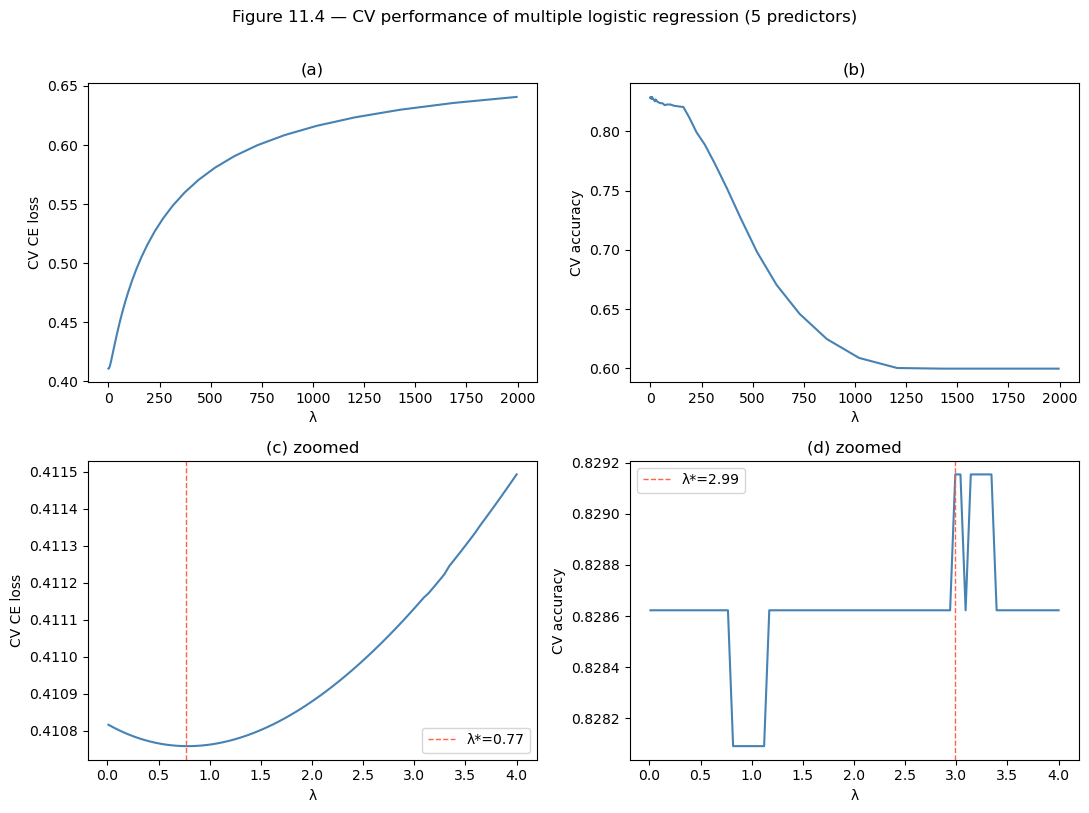

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
((ax_a, ax_b), (ax_c, ax_d)) = axes

ax_a.plot(lams_coarse, ce_cv_coarse, 'steelblue', lw=1.5)
ax_a.set_xlabel('λ'); ax_a.set_ylabel('CV CE loss'); ax_a.set_title('(a)')

ax_b.plot(lams_coarse, acc_cv_coarse, 'steelblue', lw=1.5)
ax_b.set_xlabel('λ'); ax_b.set_ylabel('CV accuracy'); ax_b.set_title('(b)')

ax_c.plot(lams_fine, ce_cv_fine, 'steelblue', lw=1.5)
ax_c.axvline(best_lam_ce, color='tomato', ls='--', lw=1, label=f'λ*={best_lam_ce:.2f}')
ax_c.set_xlabel('λ'); ax_c.set_ylabel('CV CE loss'); ax_c.set_title('(c) zoomed'); ax_c.legend()

ax_d.plot(lams_fine, acc_cv_fine, 'steelblue', lw=1.5)
ax_d.axvline(best_lam_acc, color='tomato', ls='--', lw=1, label=f'λ*={best_lam_acc:.2f}')
ax_d.set_xlabel('λ'); ax_d.set_ylabel('CV accuracy'); ax_d.set_title('(d) zoomed'); ax_d.legend()

plt.suptitle('Figure 11.4 — CV performance of multiple logistic regression (5 predictors)', y=1.01)
plt.tight_layout(); plt.show()

### Table 11.4 — Fitted coefficients at λ = 0.7

> **Book link — §11.3.5, Table 11.4.**  Fit on the full dataset with $\lambda = 0.7$.
> Bootstrap SEs use 1 000 resamples.

In [10]:
LAM_FINAL = 0.7
C_FINAL   = 1 / (2 * LAM_FINAL)
print(f"λ = {LAM_FINAL}  →  C = {C_FINAL:.4f}")

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=C_FINAL, solver='lbfgs', max_iter=1000))
])
pipe_full.fit(X5_raw, y)
beta_full = pipe_full.named_steps['clf'].coef_[0]

# Bootstrap SEs
N_BOOT2 = 1000
boot5 = np.zeros((N_BOOT2, len(FEATURE_COLS)))
for b in range(N_BOOT2):
    idx = rng.integers(0, n, size=n)
    pipe_b = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=C_FINAL, solver='lbfgs', max_iter=1000))
    ])
    pipe_b.fit(X5_raw[idx], y[idx])
    boot5[b] = pipe_b.named_steps['clf'].coef_[0]
se5 = boot5.std(axis=0)

print(f"\n{'Predictor':<30} {'β̂':>8} {'ŝe(β̂)':>10}")
print("-" * 52)
for j, name in enumerate(FEATURE_NAMES):
    print(f"{name:<30} {beta_full[j]:>8.3f} {se5[j]:>10.3f}")

res_cv = cross_validate(pipe_full, X5_raw, y, cv=cv5,
                        scoring=['neg_log_loss', 'accuracy'])
cv_ce_07  = -res_cv['test_neg_log_loss'].mean()
cv_acc_07 =  res_cv['test_accuracy'].mean()
print(f"\nCV CE loss = {cv_ce_07:.4f}   CV accuracy = {cv_acc_07:.4f}")
print("(Book: β_FBS≈1.584, β_HbA1c≈1.494, CV accuracy ≈ 0.826)")

λ = 0.7  →  C = 0.7143

Predictor                            β̂     ŝe(β̂)
----------------------------------------------------
Fasting blood sugar               1.584      0.088
Hemoglobin A1C                    1.494      0.082
Cholesterol triglycerides         0.103      0.061
Hypertension                      0.588      0.074
Socioeconomic status              0.102      0.061

CV CE loss = 0.4108   CV accuracy = 0.8286
(Book: β_FBS≈1.584, β_HbA1c≈1.494, CV accuracy ≈ 0.826)


### Figure 11.5 — 43-feature dataset (n = 300)

> **Book link — §11.3.5, Figure 11.5.**  The diabetes dataset originally has 43 features.
> We sample 300 of the 1 879 examples and apply the same CV workflow.
> With fewer examples and many more features, regularisation helps much more.

All features: 43
Wide dataset: (300, 43),  diabetes rate = 0.400


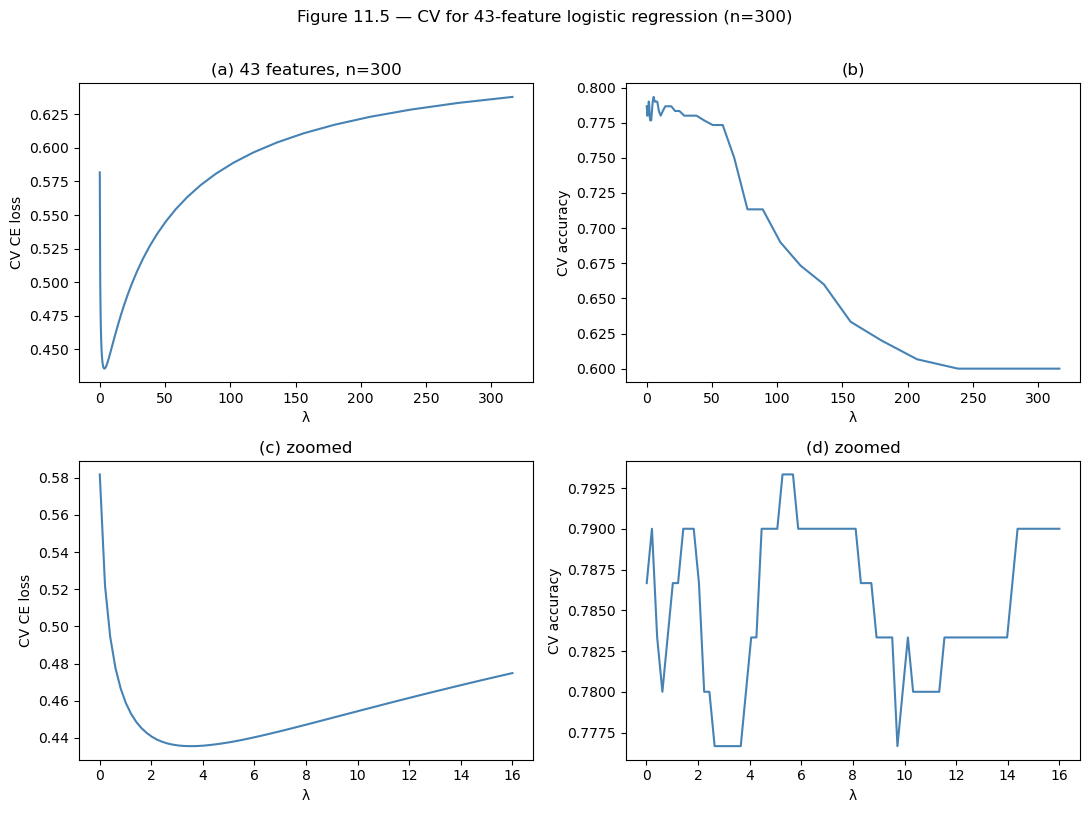

In [11]:
EXCLUDE_COLS = ['PatientID', 'DoctorInCharge', TARGET_COL]
ALL_FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]
print(f"All features: {len(ALL_FEATURE_COLS)}")

idx300  = rng.choice(n, size=300, replace=False)
X43_raw = df[ALL_FEATURE_COLS].values.astype(float)[idx300]
y300    = y[idx300]
print(f"Wide dataset: {X43_raw.shape},  diabetes rate = {y300.mean():.3f}")

cv_w = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

lams_wide = np.concatenate([[0.01], np.logspace(-0.5, 2.5, 50)])
ce_wide   = np.zeros(len(lams_wide))
acc_wide  = np.zeros(len(lams_wide))
for i, lam in enumerate(lams_wide):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1/(2*lam), solver='lbfgs', max_iter=1000))
    ])
    res = cross_validate(pipe, X43_raw, y300, cv=cv_w,
                         scoring=['neg_log_loss', 'accuracy'])
    ce_wide[i]  = -res['test_neg_log_loss'].mean()
    acc_wide[i] =  res['test_accuracy'].mean()

lams_wide_f = np.linspace(0.01, 16, 80)
ce_wide_f   = np.zeros(len(lams_wide_f))
acc_wide_f  = np.zeros(len(lams_wide_f))
for i, lam in enumerate(lams_wide_f):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1/(2*lam), solver='lbfgs', max_iter=1000))
    ])
    res = cross_validate(pipe, X43_raw, y300, cv=cv_w,
                         scoring=['neg_log_loss', 'accuracy'])
    ce_wide_f[i]  = -res['test_neg_log_loss'].mean()
    acc_wide_f[i] =  res['test_accuracy'].mean()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
((ax_a, ax_b), (ax_c, ax_d)) = axes
ax_a.plot(lams_wide,   ce_wide,    'steelblue', lw=1.5); ax_a.set_xlabel('λ'); ax_a.set_ylabel('CV CE loss');  ax_a.set_title('(a) 43 features, n=300')
ax_b.plot(lams_wide,   acc_wide,   'steelblue', lw=1.5); ax_b.set_xlabel('λ'); ax_b.set_ylabel('CV accuracy'); ax_b.set_title('(b)')
ax_c.plot(lams_wide_f, ce_wide_f,  'steelblue', lw=1.5); ax_c.set_xlabel('λ'); ax_c.set_ylabel('CV CE loss');  ax_c.set_title('(c) zoomed')
ax_d.plot(lams_wide_f, acc_wide_f, 'steelblue', lw=1.5); ax_d.set_xlabel('λ'); ax_d.set_ylabel('CV accuracy'); ax_d.set_title('(d) zoomed')
plt.suptitle('Figure 11.5 — CV for 43-feature logistic regression (n=300)', y=1.01)
plt.tight_layout(); plt.show()

---
## §11.5 Multinomial logistic regression — human speech sounds

> **Book link — §11.5.2, Figure 11.6.**  We distinguish 10 English vowel syllables (K=10)
> using formant measurements: **backness** ($X_1$) and **height** ($X_2$).
> Data: Clopper et al. (2005), 48 speakers, n=2 371 utterances.

Vowel dataset: 2371 utterances, 10 classes


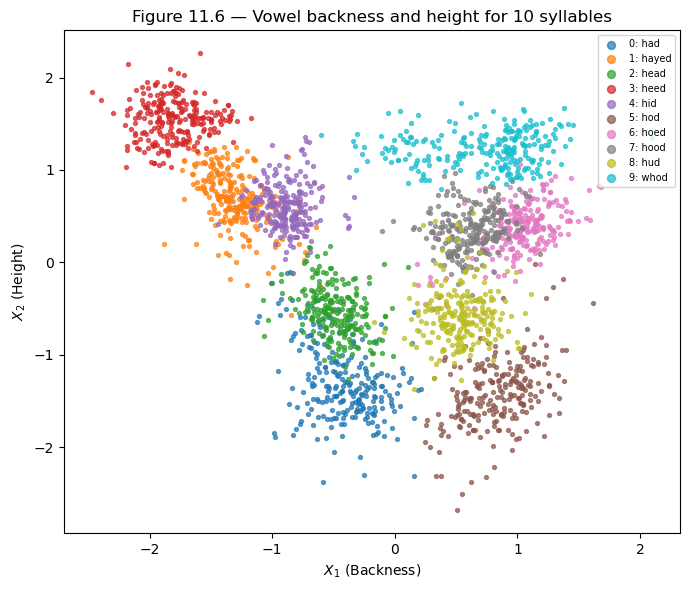

In [12]:
vdf = pd.read_csv(DATA_PATH + 'Vowels_Processed.csv')

# 10 standard h_Vd frame vowels (filter out 'frogs' and 'logs')
HVD_CLASSES = ['had', 'hayed', 'head', 'heed', 'hid', 'hod', 'hoed', 'hood', 'hud', 'whod']
vdf = vdf[vdf['Target'].isin(HVD_CLASSES)].copy().reset_index(drop=True)
print(f"Vowel dataset: {len(vdf)} utterances, {vdf['Target'].nunique()} classes")

# Integer-encode the target
vdf['class_id'] = vdf['Target'].map({v: i for i, v in enumerate(HVD_CLASSES)})
Xv   = vdf[['Backness', 'Height']].values.astype(float)   # (2371, 2)
yv   = vdf['class_id'].values                              # (2371,)
Kv   = len(HVD_CLASSES)
COLORS_10 = [f'C{i}' for i in range(10)]

# Figure 11.6 — scatter plot
fig, ax = plt.subplots(figsize=(7, 6))
for k, name in enumerate(HVD_CLASSES):
    mask = (yv == k)
    ax.scatter(Xv[mask, 0], Xv[mask, 1], c=COLORS_10[k], s=8, alpha=0.7,
               label=f'{k}: {name}')
ax.set_xlabel('$X_1$ (Backness)'); ax.set_ylabel('$X_2$ (Height)')
ax.set_title('Figure 11.6 — Vowel backness and height for 10 syllables')
ax.legend(fontsize=7, markerscale=2, loc='upper right')
plt.tight_layout(); plt.show()

---
## §11.5.2 Multinomial logistic regression on vowels

> **Book link — §11.5.1–11.5.2.**  For $K > 2$ classes, `LogisticRegression` with
> `solver='lbfgs'` automatically uses the multinomial (softmax) objective.
> The $\lambda \leftrightarrow C$ correspondence $C = 1/(2\lambda)$ applies unchanged.

In [13]:
cv_v = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

lams_v = np.linspace(0.001, 0.01, 50)
ce_v   = np.zeros(len(lams_v))
acc_v  = np.zeros(len(lams_v))

for i, lam in enumerate(lams_v):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1/(2*lam), solver='lbfgs', max_iter=1000))
    ])
    res = cross_validate(pipe, Xv, yv, cv=cv_v,
                         scoring=['neg_log_loss', 'accuracy'])
    ce_v[i]  = -res['test_neg_log_loss'].mean()
    acc_v[i] =  res['test_accuracy'].mean()

best_lam_v = lams_v[ce_v.argmin()]
print(f"Best λ (CE) = {best_lam_v:.4f}  (C = {1/(2*best_lam_v):.1f})")
print(f"Best CV accuracy = {acc_v.max():.4f}")
print("(Book: λ ≈ 0.002, accuracy ≈ 0.889)")

Best λ (CE) = 0.0025  (C = 202.5)
Best CV accuracy = 0.8878
(Book: λ ≈ 0.002, accuracy ≈ 0.889)


### Figure 11.7 — Cross-validation for multinomial logistic regression on vowels

> **Book link — §11.5.2, Figure 11.7.**  Very light regularisation ($\lambda \approx 0.002$)
> is optimal.  The dataset is tall ($n=2371$) and the feature space small ($p=2$),
> so overfitting risk is low.

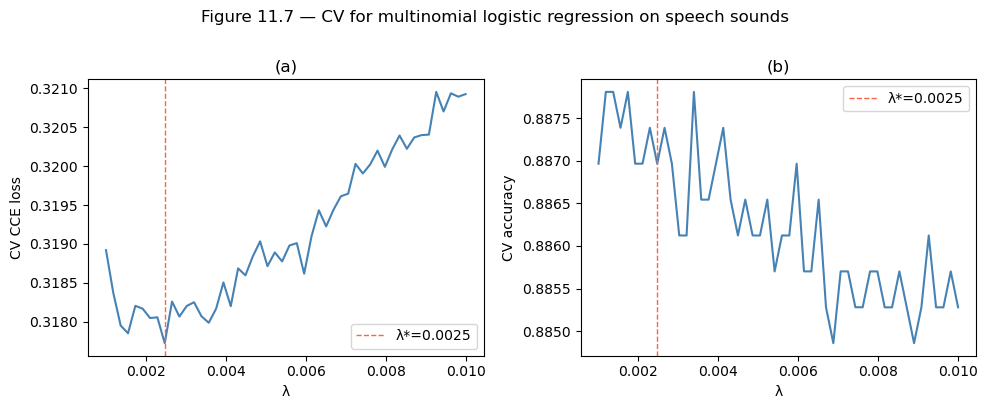

In [14]:
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(10, 4))

ax_a.plot(lams_v, ce_v, 'steelblue', lw=1.5)
ax_a.axvline(best_lam_v, color='tomato', ls='--', lw=1, label=f'λ*={best_lam_v:.4f}')
ax_a.set_xlabel('λ'); ax_a.set_ylabel('CV CCE loss'); ax_a.set_title('(a)'); ax_a.legend()

ax_b.plot(lams_v, acc_v, 'steelblue', lw=1.5)
ax_b.axvline(best_lam_v, color='tomato', ls='--', lw=1, label=f'λ*={best_lam_v:.4f}')
ax_b.set_xlabel('λ'); ax_b.set_ylabel('CV accuracy'); ax_b.set_title('(b)'); ax_b.legend()

plt.suptitle('Figure 11.7 — CV for multinomial logistic regression on speech sounds', y=1.01)
plt.tight_layout(); plt.show()

### Figure 11.8 — Decision regions of the fitted multinomial logistic regression model

> **Book link — §11.5.2, Figure 11.8.**  Background colour = best-guess class label;
> opacity = classifier confidence.  Boundaries between decision regions are straight lines
> (because scores are linear in $\mathbf{x}$).

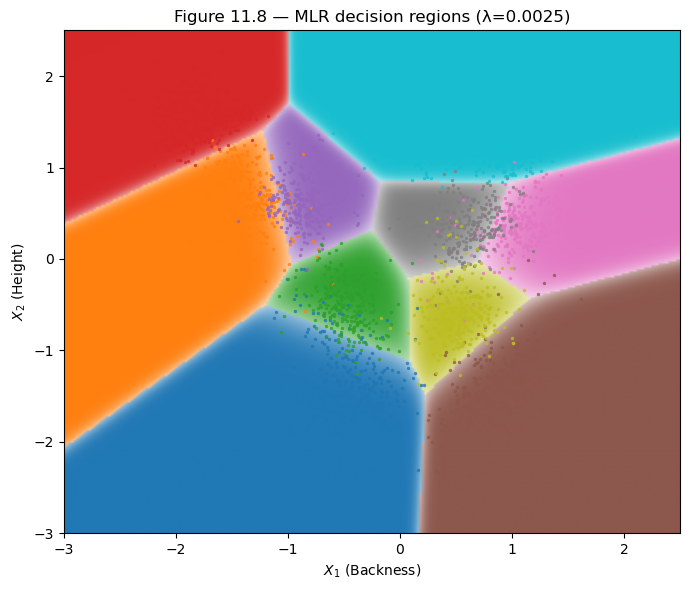

In [15]:
LAM_V = best_lam_v
XLIM  = (-3.0, 2.5); YLIM = (-3.0, 2.5)

# Fit multinomial LR on the full vowel dataset
pipe_v = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1/(2*LAM_V), solver='lbfgs', max_iter=1000))
])
pipe_v.fit(Xv, yv)

def make_background(ax, proba_fn, xlim, ylim, colors, ngrid=250):
    """Fill decision regions with colour opacity proportional to classifier confidence."""
    x1 = np.linspace(*xlim, ngrid)
    x2 = np.linspace(*ylim, ngrid)
    xx, yy = np.meshgrid(x1, x2)
    grid = np.c_[xx.ravel(), yy.ravel()]
    P    = proba_fn(grid)
    best = P.argmax(1)
    conf = P.max(1)
    rgba = np.zeros((ngrid * ngrid, 4))
    for k, c in enumerate(colors):
        m = (best == k)
        rgba[m, :3] = np.array(mcolors.to_rgb(c))
        rgba[m, 3]  = conf[m]
    ax.imshow(rgba.reshape(ngrid, ngrid, 4),
              extent=[*xlim, *ylim], origin='lower', aspect='auto', interpolation='bilinear')

fig, ax = plt.subplots(figsize=(7, 6))
make_background(ax, pipe_v.predict_proba, XLIM, YLIM, COLORS_10)
for k, name in enumerate(HVD_CLASSES):
    mask = (yv == k)
    ax.scatter(Xv[mask, 0], Xv[mask, 1], c=COLORS_10[k], s=6, alpha=0.8, linewidths=0)
ax.set_xlim(XLIM); ax.set_ylim(YLIM)
ax.set_xlabel('$X_1$ (Backness)'); ax.set_ylabel('$X_2$ (Height)')
ax.set_title(f'Figure 11.8 — MLR decision regions (λ={LAM_V:.4f})')
plt.tight_layout(); plt.show()

---
## §11.6 $k$-nearest neighbours

> **Book link — §11.6.1.**  k-NN is a non-parametric classifier.  For an unlabelled point $\mathbf{x}$,
> the predicted class probabilities are the empirical distribution of class labels among the
> $k$ nearest training points (by Euclidean distance after standardisation).

> **Book link — §11.6.2, Figure 11.9.**  Cross-validated accuracy peaks around $k \approx 18$.

In [16]:
cv_knn = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
K_VALUES   = np.arange(1, 201)
acc_knn_cv = np.zeros(len(K_VALUES))

for ki, k in enumerate(K_VALUES):
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k))
    ])
    acc_knn_cv[ki] = cross_val_score(pipe_k, Xv, yv, cv=cv_knn,
                                     scoring='accuracy').mean()

best_k = K_VALUES[acc_knn_cv.argmax()]
print(f"Best k = {best_k},  CV accuracy = {acc_knn_cv.max():.4f}")

Best k = 18,  CV accuracy = 0.8984


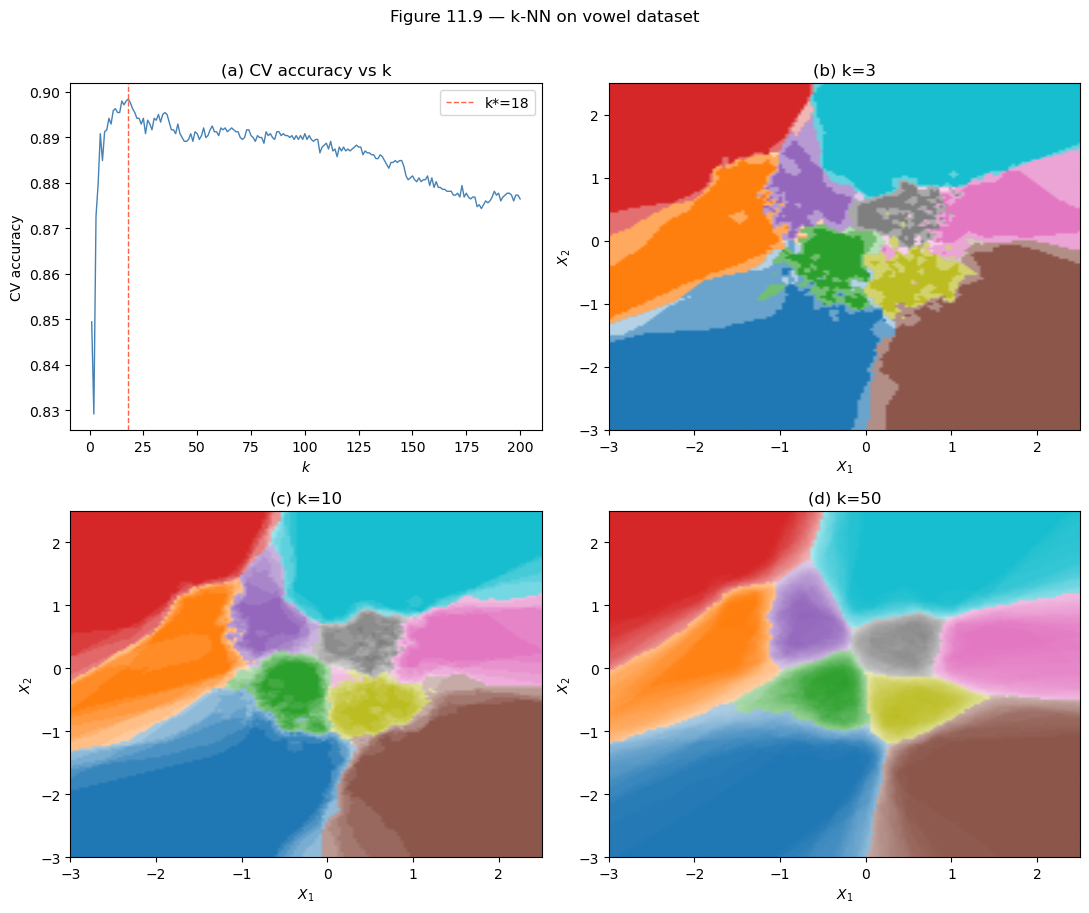

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

ax_a = axes[0, 0]
ax_a.plot(K_VALUES, acc_knn_cv, 'steelblue', lw=1)
ax_a.axvline(best_k, color='tomato', ls='--', lw=1, label=f'k*={best_k}')
ax_a.set_xlabel('$k$'); ax_a.set_ylabel('CV accuracy')
ax_a.set_title('(a) CV accuracy vs k'); ax_a.legend()

for ax, k_val, label in zip([axes[0,1], axes[1,0], axes[1,1]],
                              [3, 10, 50], ['(b) k=3', '(c) k=10', '(d) k=50']):
    pipe_k = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k_val))
    ])
    pipe_k.fit(Xv, yv)
    make_background(ax, pipe_k.predict_proba, XLIM, YLIM, COLORS_10, ngrid=150)
    ax.set_xlim(XLIM); ax.set_ylim(YLIM)
    ax.set_xlabel('$X_1$'); ax.set_ylabel('$X_2$')
    ax.set_title(label)

plt.suptitle('Figure 11.9 — k-NN on vowel dataset', y=1.01)
plt.tight_layout(); plt.show()

---
## §11.7 Multinomial logistic regression vs k-NN in higher dimensions

> **Book link — §11.7, Table 11.5.**  We restore two additional feature groups:
> **duration** (one continuous feature) and **dialect** (six one-hot columns for
> Mid-Atlantic, Midland, New England, North, South, West),
> giving a 9-dimensional predictor space.
>
> Parametric methods (MLR) tend to outperform distance-based ones (k-NN) as $p$ grows.

In [18]:
DIALECT_LABELS = ['Mid-Atlantic', 'Midland', 'NewEngland', 'North', 'South', 'West']
dial_oh = np.zeros((len(vdf), len(DIALECT_LABELS)))
for j, d in enumerate(DIALECT_LABELS):
    dial_oh[:, j] = (vdf['Dialect'] == d).astype(float)

Xv9 = np.column_stack([Xv, vdf['duration'].values, dial_oh])
print(f"Extended feature matrix: {Xv9.shape}")

cv9 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Multinomial LR
lams_v9 = np.linspace(0.001, 0.05, 30)
acc_v9  = np.zeros(len(lams_v9))
for i, lam in enumerate(lams_v9):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(C=1/(2*lam), solver='lbfgs', max_iter=1000))
    ])
    acc_v9[i] = cross_val_score(pipe, Xv9, yv, cv=cv9, scoring='accuracy').mean()

best_lam_v9 = lams_v9[acc_v9.argmax()]
print(f"MLR (9 features): best λ={best_lam_v9:.4f}  (C={1/(2*best_lam_v9):.1f}),  "
      f"CV accuracy={acc_v9.max():.4f}")

# k-NN
k_vals_9 = np.arange(1, 31)
acc_knn9 = np.zeros(len(k_vals_9))
for ki, k in enumerate(k_vals_9):
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(n_neighbors=k))
    ])
    acc_knn9[ki] = cross_val_score(pipe, Xv9, yv, cv=cv9, scoring='accuracy').mean()

best_k9 = k_vals_9[acc_knn9.argmax()]
print(f"k-NN (9 features): best k={best_k9},  CV accuracy={acc_knn9.max():.4f}")

Extended feature matrix: (2371, 9)
MLR (9 features): best λ=0.0111  (C=44.9),  CV accuracy=0.9140
k-NN (9 features): best k=4,  CV accuracy=0.9000


---
## Exercises

### Exercise 1 — Log-odds interpretation (Book Exercise 11.7)

Starting from a prior probability of diabetes of 40%, compute the revised probability
if the log odds increase by:
(a) 1.08 (one standard deviation increase in fasting blood sugar);
(b) 0.037 (one standard deviation increase in cholesterol triglycerides).

Use the formula: if the prior log odds are $\ell_0 = \log(\pi/(1-\pi))$ and
the log odds increase by $\delta$, the posterior probability is $\sigma(\ell_0 + \delta)$.

In [19]:
# Your answer here
pi_prior = 0.4
# log_odds_prior = ...
# revised_prob_a  = ...
# revised_prob_b  = ...

In [20]:
# Solution
pi_prior = 0.4
lo0 = np.log(pi_prior / (1 - pi_prior))   # log-odds at base rate ≈ −0.405

for delta, label in [(1.08, 'FBS (δ=1.08)'), (0.037, 'Chol (δ=0.037)')]:
    rev = 1 / (1 + np.exp(-(lo0 + delta)))
    print(f"{label}: revised P(diabetes) = {rev:.4f}")

FBS (δ=1.08): revised P(diabetes) = 0.6625
Chol (δ=0.037): revised P(diabetes) = 0.4089


### Exercise 2 — Baseline cross-entropy loss (Book Exercise 11.10)

A classifier that always predicts the training base rate $\hat\pi$ achieves a specific
cross-entropy loss.  Compute this for the diabetes dataset and verify it matches the
"uninformative predictor" limit seen in Figure 11.4.

In [21]:
# Your answer here
# baseline_ce = ...

In [22]:
# Solution
pi_hat = y.mean()
baseline_ce = -(pi_hat * np.log(pi_hat) + (1 - pi_hat) * np.log(1 - pi_hat))
print(f"Base rate π̂ = {pi_hat:.4f}")
print(f"Baseline CE loss = {baseline_ce:.4f}")
print("This matches the plateau seen in Figure 11.4(a) as λ → ∞.")

Base rate π̂ = 0.4002
Baseline CE loss = 0.6731
This matches the plateau seen in Figure 11.4(a) as λ → ∞.


### Exercise 3 — The softmax reduces to sigmoid for K = 2

> **Book link — §11.5.1.**  The multinomial model with $K=2$ is mathematically equivalent
> to binary logistic regression.  Verify this numerically: fit `LogisticRegression` in
> binary mode and in its default (multinomial) mode on the diabetes dataset using all five
> predictors with $\lambda = 0.7$.  Compare the predicted probabilities from the two fits.

In [23]:
# Your answer here
# C_EX = 1 / (2 * 0.7)
# pipe_bin = Pipeline([...])
# pipe_mn  = Pipeline([...])
# ...

# ── Solution ──────────────────────────────────────────────────────────────────
C_EX = 1 / (2 * 0.7)

pipe_bin = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=C_EX, solver='lbfgs', max_iter=1000))
])
pipe_mn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=C_EX, solver='lbfgs', max_iter=1000))
])

pipe_bin.fit(X5_raw, y)
pipe_mn.fit(X5_raw, y.astype(int))

p_bin = pipe_bin.predict_proba(X5_raw)[:, 1]
p_mn  = pipe_mn.predict_proba(X5_raw)[:, 1]

print(f"Max |p_bin − p_mn| = {np.abs(p_bin - p_mn).max():.6f}")
print("→ Both models assign (nearly) identical probabilities, confirming equivalence.")

Max |p_bin − p_mn| = 0.000000
→ Both models assign (nearly) identical probabilities, confirming equivalence.
